In [1]:
from pathlib import Path

import cv2  # for INTER_NEAREST resize
import numpy as np

# Config
SEED = 42
RESIZE = 64  # Target H = W = 64
DATA_DIR = Path("../data")
CLEAN_PKL = DATA_DIR / "LSWMD_clean.pkl"
OUT_DIR = DATA_DIR / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEFECT_CLASSES = ["Edge-Ring", "Edge-Loc", "Center", "Loc", "Scratch", "Random", "Donut", "Near-full"]

TEST_SIZE = 0.15
VAL_SIZE = 0.15

np.random.seed(SEED)

In [2]:
import pandas as pd

df = pd.read_pickle(CLEAN_PKL)
print(f"Loaded: {df.shape}")  # Should be (811457, 6)


# Flatten the doubly-nested label [[none]] -> "none"
# WM-811K stores failureType / trianTestLabel as nested arrays, e.g. [['none']]
# We need a flat string column for filtering, stratifying, and Parquet output.
def flatten_label(x):
    """Return the scalar label from a (possibly) nested array.)"""
    arr = np.asarray(x).flatten()
    return str(arr[0]) if arr.size > 0 else ""


df["label"] = df["failureType"].apply(flatten_label)

# sanity check, distribution must match
print(df["label"].value_counts())


Loaded: (811457, 6)
label
             638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [3]:
# Keep only the 8 defect classes (whitelist)
# Whitelist > blacklist here: anything not a real defect ("" / none) is
# drop automatically, no need to enumerate every junk value
before = len(df)
df = df[df["label"].isin(DEFECT_CLASSES)].reset_index(drop=True)
after = len(df)

print(f"Filtered: {before} -> {after} rows ({before - after} dropped)")
print(df["label"].value_counts())

# Quick assert: we must end up with exactly the 8 classes, nothing else
assert set(df["label"].unique()) == set(DEFECT_CLASSES), "Unexpected labels remain!"
print("Exactly 8 defect classes remain!")


Filtered: 811457 -> 25519 rows (785938 dropped)
label
Edge-Ring    9680
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
Name: count, dtype: int64
Exactly 8 defect classes remain!


In [4]:
import matplotlib.pyplot as plt


# Resize function: nearest-neighbor to preserve discrete die values
def resize_wafer(wm, size=RESIZE):
    """Resize a wafer map to size x size using INTER_NEAREST.
    INTER_NEAREST is mandatory: die values are discrete {0, 1, 2}.
    Any interpolating method (bilinear/bicubic) would create meaningless
    fractional values (e.g. 0.7) that break the 'good/bad' die semantics.
    Trade-off: nearest can drop/duplicate sparse defect die locally, but it preserves value
    semantics - see docs/IDEAS.md for the lossy-transform note.
    """
    arr = np.asarray(wm, dtype=np.uint8)
    return cv2.resize(arr, (size, size), interpolation=cv2.INTER_NEAREST)


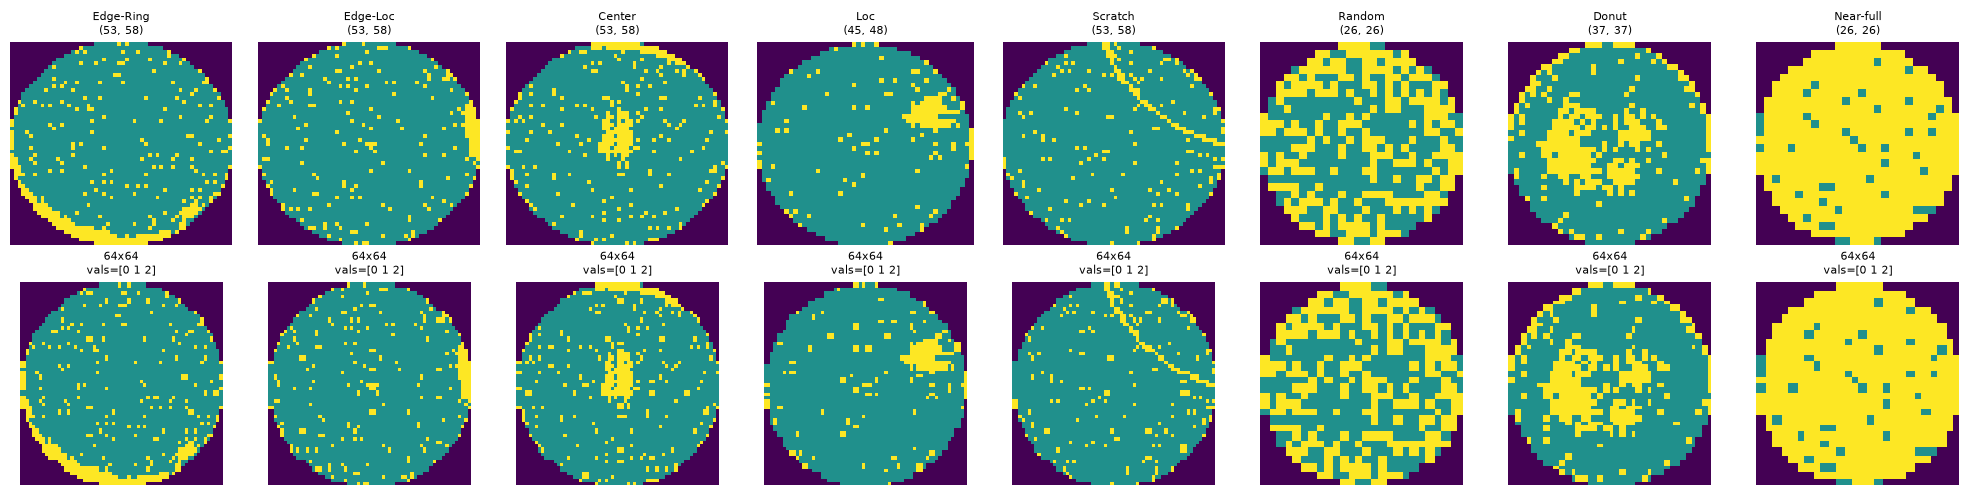

In [5]:
# Visual check: one sample per defect class, after resize
# We must eyeball this: confirm the defect pattern survives the resize
# and that resize values stay within {0,1,2}
fig, axes = plt.subplots(2, len(DEFECT_CLASSES), figsize=(20, 5))

for col, cls in enumerate(DEFECT_CLASSES):
    sample = df[df["label"] == cls].iloc[0]["waferMap"]
    sample = np.asarray(sample, dtype=np.uint8)
    resized = resize_wafer(sample)

    axes[0, col].imshow(sample, cmap="viridis")
    axes[0, col].set_title(f"{cls}\n{sample.shape}", fontsize=8)
    axes[0, col].axis("off")

    axes[1, col].imshow(resized, cmap="viridis")
    axes[1, col].set_title(f"{RESIZE}x{RESIZE}\nvals={np.unique(resized)}", fontsize=8)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Resized", fontsize=10)

plt.tight_layout()
plt.show()

In [6]:
# Apply resize to all samples
# New column wafer _64: every map now a uniform 64x64 uint8 array
df["wafer_64"] = df["waferMap"].apply(resize_wafer)
print(f"Resize all {len(df)} wafers to {RESIZE}x{RESIZE}")
print("Sample shape:", df["wafer_64"].iloc[0].shape)  # expect (64, 64)

Resize all 25519 wafers to 64x64
Sample shape: (64, 64)


In [7]:
from sklearn.model_selection import train_test_split

# Stratified train/val/test split (70/15/15)
# Stratify is mandatory: classes are highly imbalanced (Near-full = 149)
# A plain random split could leave a class absent from val/test
# train_test_split divides in two, so we split twice

# Step 1: carve out the test set 15%
df_trainval, def_test = train_test_split(df, test_size=TEST_SIZE, stratify=df["label"], random_state=SEED)

# Step 2: split the remaining 85% into train and val.
# We want val = 15% of the ORIGINAL total, so as a fraction of the
# remaining 85% that is 0.15 / 0.85
val_relative = VAL_SIZE / (1 - TEST_SIZE)
df_train, df_val = train_test_split(df_trainval, test_size=val_relative, stratify=df_trainval["label"],
                                    random_state=SEED)

print("Split sizes:")
print(f"\ttrain: {len(df_train)} ({len(df_train) / len(df):.1%})")
print(f"\tval:   {len(df_val)} ({len(df_val) / len(df):.1%})")
print(f"\ttest:  {len(def_test)} ({len(def_test) / len(df):.1%})")

# Verify stratification held: per-class proportions should match across splits
print("\nPer-class proportion check:")
prop = pd.DataFrame({
    "train": df_train["label"].value_counts(normalize=True),
    "val": df_val["label"].value_counts(normalize=True),
    "test": def_test["label"].value_counts(normalize=True),
}).round(3)

print(prop)

Split sizes:
	train: 17863 (70.0%)
	val:   3828 (15.0%)
	test:  3828 (15.0%)

Per-class proportion check:
           train    val   test
label                         
Edge-Ring  0.379  0.379  0.379
Edge-Loc   0.203  0.203  0.204
Center     0.168  0.168  0.168
Loc        0.141  0.141  0.141
Scratch    0.047  0.047  0.047
Random     0.034  0.034  0.034
Donut      0.022  0.022  0.022
Near-full  0.006  0.006  0.006


In [8]:
import pyarrow as pa


def to_parquet_df(split_df):
    """Build a clean DataFrame ready for Parquet from a split"""
    out = pd.DataFrame({
        "wafer": split_df["wafer_64"].apply(lambda a: a.astype(np.uint8).flatten()),  # convert (64, 64) to (4096,)
        "label": split_df["label"].values,
        "lotName": split_df["lotName"].values,
        "waferIndex": split_df["waferIndex"].values,
    })

    return out


splits = {"train": df_train, "val": df_val, "test": def_test}

for name, split_df in splits.items():
    out_df = to_parquet_df(split_df)
    out_path = OUT_DIR / f"{name}.parquet"
    out_df.to_parquet(out_path, engine="pyarrow", compression="snappy", index=False)
    print(f"Wrote {out_path} ({len(out_df)} rows, {out_df.memory_usage(deep=True).sum() / 1e6:.1f} MB)")

print("All splits written to Parquet!")


Wrote ../data/processed/train.parquet (17863 rows, 78.0 MB)
Wrote ../data/processed/val.parquet (3828 rows, 16.7 MB)
Wrote ../data/processed/test.parquet (3828 rows, 16.7 MB)
All splits written to Parquet!


Read back train: (17863, 4)
Columns: ['wafer', 'label', 'lotName', 'waferIndex']
Labels: {'Edge-Ring': 6776, 'Edge-Loc': 3632, 'Center': 3006, 'Loc': 2515, 'Scratch': 835, 'Random': 606, 'Donut': 389, 'Near-full': 104}
Reconstructed wafer shape:  {(64, 64)} | unique vals: [0 1 2]


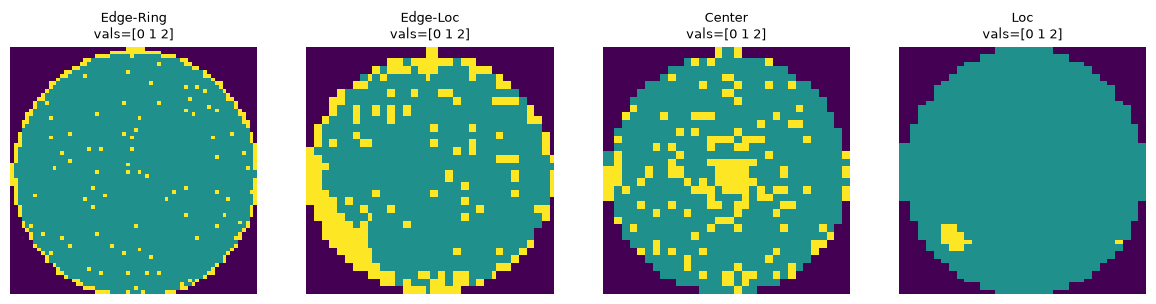

Round trip OK!


In [9]:
# Verify round trip, read back Parquet and reconstruct
# Quality gate: confirm what we wrote reads back indentically
df_check = pd.read_parquet(OUT_DIR / "train.parquet", engine="pyarrow")
print(f"Read back train: {df_check.shape}")
print("Columns:", df_check.columns.tolist())
print("Labels:", df_check["label"].value_counts().to_dict())

# Reconstruct on wafer: flat(4096,) -> (64, 64)
flat = np.asarray(df_check["wafer"].iloc[0], dtype=np.uint8)
img = flat.reshape(RESIZE, RESIZE)
print("Reconstructed wafer shape: ", {img.shape}, "| unique vals:", np.unique(img))

# Visual check: a few wafers per first 4 classes, read straight from Parquet
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, cls in zip(axes, DEFECT_CLASSES[:4]):
    row = df_check[df_check["label"] == cls].iloc[0]
    wafer = np.asarray(row["wafer"], dtype=np.uint8).reshape(RESIZE, RESIZE)
    ax.imshow(wafer, cmap="viridis")
    ax.set_title(f"{cls}\nvals={np.unique(wafer)}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

assert set(np.unique(img)).issubset({0, 1, 2}), "Round trip corrupted values!"
print("Round trip OK!")